<a href="https://colab.research.google.com/github/saismaran-epari/Master-s-Thesis-on-Image-Processing-/blob/main/Image_Reconstruction_using_SWin_Transformer_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt

# 1. Hardware Detection (Supports Mac MPS, Nvidia CUDA, and CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps') # For Apple Silicon Macs
else:
    device = torch.device('cpu')
print(f"Using device: {device}")


import os
from PIL import Image
from torchvision import transforms

class RealSRDataset(torch.utils.data.Dataset):
    def __init__(self, hr_dir, patch_size=32, scale=2):
        """
        hr_dir: Path to your folder containing the High-Resolution DIV2K images.
        patch_size: The size of the Low-Resolution input patch.
        scale: The Super-Resolution scale factor (e.g., x2).
        """
        self.hr_dir = hr_dir
        self.patch_size = patch_size
        self.scale = scale

        # Grab all the PNG/JPG files in your directory
        self.image_files = [f for f in os.listdir(hr_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

        if len(self.image_files) == 0:
            raise ValueError(f"No images found in '{hr_dir}'. Please check your folder path!")

    def __len__(self):
        # We can artificially inflate the "length" of the dataset since we are taking
        # random crops every time, meaning the network sees new data constantly.
        # But for now, we'll just return the number of images.
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Load the High-Resolution image
        img_path = os.path.join(self.hr_dir, self.image_files[idx])
        hr_img = Image.open(img_path).convert('RGB')

        # 2. Calculate the size of the HR patch
        hr_patch_size = self.patch_size * self.scale

        # 3. Extract a random square crop and convert it to a PyTorch tensor [0.0 to 1.0]
        transform_hr = transforms.Compose([
            transforms.RandomCrop(hr_patch_size),
            transforms.ToTensor()
        ])
        hr_tensor = transform_hr(hr_img)

        # 4. Create the Low-Resolution counterpart using bicubic downsampling
        # We add a batch dimension, interpolate, and then remove the batch dimension
        lr_tensor = F.interpolate(
            hr_tensor.unsqueeze(0),
            scale_factor=1/self.scale,
            mode='bicubic',
            align_corners=False
        ).squeeze(0)

        # Clamp values just in case the math pushes pixels slightly outside standard color bounds
        lr_tensor = torch.clamp(lr_tensor, 0.0, 1.0)

        return lr_tensor, hr_tensor

# --- Folder Setup ---
# Make sure your folder structure looks like this relative to your notebook:
# 📁 dataset/
#    📁 DIV2K_train_HR/  <-- Put your 50 downloaded images in here!

hr_directory = "/content/drive/MyDrive/HR images" # Update this string to your actual folder path

# Initialize the Real Dataset and DataLoader
train_dataset = RealSRDataset(hr_dir=hr_directory, patch_size=32, scale=2)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)

print(f"Successfully loaded {len(train_dataset)} high-resolution images!")

Using device: cuda
Successfully loaded 54 high-resolution images!


In [ ]:
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    """Multi-head self-attention with relative position bias."""
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5

        # Learnable relative positional encoding B [cite: 150]
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads))

        # Setup relative position index
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        # Apply relative position bias B [cite: 149, 150]
        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1], self.window_size[0] * self.window_size[1], -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)

        # APPLY THE COMPLEX MASK
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x

In [ ]:
class SwinTransformerLayer(nn.Module):
    def __init__(self, dim, num_heads, window_size=8, shift_size=0):
        super().__init__()
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size=(window_size, window_size), num_heads=num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x, H, W):
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        # Cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

            # CALCULATE NO-SHORTCUT MASK
            img_mask = torch.zeros((1, H, W, 1), device=x.device)
            h_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, self.window_size)
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            shifted_x = x
            attn_mask = None

        # Partition windows & Attention
        x_windows = window_partition(shifted_x, self.window_size).view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(x_windows, mask=attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        # Reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

class RSTB(nn.Module):
    """Residual Swin Transformer Block [cite: 128]"""
    def __init__(self, dim, num_heads, window_size, depth):
        super().__init__()
        self.layers = nn.ModuleList([
            SwinTransformerLayer(
                dim=dim, num_heads=num_heads, window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2
            ) for i in range(depth)
        ])
        # Convolutional layer at the end of the RSTB [cite: 133, 134]
        self.conv = nn.Conv2d(dim, dim, 3, 1, 1)

    def forward(self, x, H, W):
        B, C, H_in, W_in = x.shape
        x_flat = x.flatten(2).transpose(1, 2)
        shortcut = x_flat
        for layer in self.layers:
            x_flat = layer(x_flat, H, W)
        x_out = x_flat.transpose(1, 2).view(B, C, H, W)
        return self.conv(x_out) + x # Residual connection [cite: 138]

In [ ]:
class SwinIR(nn.Module):
    def __init__(self, in_chans=3, embed_dim=60, depths=[4, 4, 4, 4], num_heads=[6, 6, 6, 6], window_size=8, scale=2):
        super().__init__()

        # 1. Shallow Feature Extraction: 3x3 convolution layer [cite: 84]
        self.conv_first = nn.Conv2d(in_chans, embed_dim, 3, 1, 1)

        # 2. Deep Feature Extraction: K residual Swin Transformer blocks [cite: 92]
        self.layers = nn.ModuleList()
        for i in range(len(depths)):
            layer = RSTB(dim=embed_dim, num_heads=num_heads[i], window_size=window_size, depth=depths[i])
            self.layers.append(layer)
        self.conv_after_body = nn.Conv2d(embed_dim, embed_dim, 3, 1, 1)

        # 3. High-Quality Image Reconstruction
        # We use the sub-pixel convolution layer to upsample the feature [cite: 114]
        self.upsample = nn.Sequential(
            nn.Conv2d(embed_dim, 64 * (scale ** 2), 3, 1, 1),
            nn.PixelShuffle(scale),
            nn.Conv2d(64, in_chans, 3, 1, 1)
        )

    def forward(self, x):
        H, W = x.shape[2:]

        # Padding to ensure image size is divisible by window size
        pad_b = (8 - H % 8) % 8
        pad_r = (8 - W % 8) % 8
        x = F.pad(x, (0, pad_r, 0, pad_b))
        H_pad, W_pad = x.shape[2:]

        # Extract features and aggregate [cite: 108]
        x_first = self.conv_first(x)
        res = x_first
        for layer in self.layers:
            res = layer(res, H_pad, W_pad)
        res = self.conv_after_body(res)

        # Long skip connection to transmit low-frequency info directly to reconstruction [cite: 113]
        x_fused = x_first + res

        # Reconstruct and crop back to original size
        x_out = self.upsample(x_fused)
        return x_out[:, :, :H*2, :W*2]

In [ ]:
def calculate_psnr(img1, img2):
    """Calculates Peak Signal-to-Noise Ratio for evaluation."""
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(1.0 / math.sqrt(mse))

# Initialize Model
model = SwinIR(embed_dim=60, depths=[4, 4, 4, 4], num_heads=[6, 6, 6, 6], scale=2).to(device)

# L1 pixel loss
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

print("Starting Training...")


# Create empty lists to store our data
history_loss = []
history_psnr = []
history_ssim = []

epochs = 50

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)

        optimizer.zero_grad()
        sr = model(lr)
        loss = criterion(sr, hr)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history_loss.append(avg_loss)

    # Evaluate at the end of every epoch to track PSNR/SSIM progress
    model.eval()
    with torch.no_grad():
        test_lr, test_hr = train_dataset[0] # Grab one static test image
        test_lr = test_lr.unsqueeze(0).to(device)
        test_hr = test_hr.unsqueeze(0).to(device)

        test_sr = model(test_lr)

        psnr_val = calculate_psnr(test_sr, test_hr)
        ssim_val = calculate_ssim(test_sr, test_hr)

        history_psnr.append(psnr_val)
        history_ssim.append(ssim_val)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} | PSNR: {psnr_val:.2f}dB | SSIM: {ssim_val:.4f}")

Starting Training...
Epoch [1/50] - Loss: 0.2140 | PSNR: 15.52dB | SSIM: 0.1130
Epoch [2/50] - Loss: 0.1255 | PSNR: 19.45dB | SSIM: 0.2701
Epoch [3/50] - Loss: 0.0949 | PSNR: 16.50dB | SSIM: 0.2334
Epoch [4/50] - Loss: 0.0776 | PSNR: 21.91dB | SSIM: 0.4700
Epoch [5/50] - Loss: 0.0667 | PSNR: 24.66dB | SSIM: 0.5607
Epoch [6/50] - Loss: 0.0769 | PSNR: 19.92dB | SSIM: 0.5882
Epoch [7/50] - Loss: 0.0783 | PSNR: 23.54dB | SSIM: 0.7079
Epoch [8/50] - Loss: 0.0598 | PSNR: 25.09dB | SSIM: 0.7105
Epoch [9/50] - Loss: 0.0567 | PSNR: 22.71dB | SSIM: 0.6841
Epoch [10/50] - Loss: 0.0471 | PSNR: 29.60dB | SSIM: 0.7952
Epoch [11/50] - Loss: 0.0399 | PSNR: 30.11dB | SSIM: 0.7904
Epoch [12/50] - Loss: 0.0443 | PSNR: 27.57dB | SSIM: 0.8611
Epoch [13/50] - Loss: 0.0450 | PSNR: 24.19dB | SSIM: 0.7141
Epoch [14/50] - Loss: 0.0435 | PSNR: 28.85dB | SSIM: 0.8865
Epoch [15/50] - Loss: 0.0433 | PSNR: 27.26dB | SSIM: 0.8592
Epoch [16/50] - Loss: 0.0408 | PSNR: 23.97dB | SSIM: 0.7425
Epoch [17/50] - Loss: 0.0396

In [ ]:
from skimage.metrics import structural_similarity as ssim_metric
import numpy as np

def calculate_ssim(img1_tensor, img2_tensor):
    """Calculates SSIM between two PyTorch tensors."""
    # Convert tensors to numpy arrays of shape (H, W, C)
    img1 = img1_tensor.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
    img2 = img2_tensor.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)

    # Clip values to ensure they stay strictly within [0.0, 1.0]
    img1 = np.clip(img1, 0, 1)
    img2 = np.clip(img2, 0, 1)

    # Calculate SSIM specifying the color channel axis
    score = ssim_metric(img1, img2, data_range=1.0, channel_axis=-1)
    return score

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_advanced_results(lr_tensor, sr_tensor, hr_tensor, zoom_coord=(10, 10), zoom_size=15):
    """
    Plots LR, SR, HR, their zoomed patches, and the Difference Map.
    zoom_coord: (x, y) starting coordinates for the zoom box.
    zoom_size: width and height of the zoom box.
    """
    # Convert tensors to numpy images
    lr_img = lr_tensor.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
    sr_img = sr_tensor.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0).clip(0, 1)
    hr_img = hr_tensor.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)

    # Calculate Difference Map (Absolute difference between SR and HR)
    # We take the mean across RGB channels to get a single grayscale heat map
    diff_map = np.mean(np.abs(sr_img - hr_img), axis=-1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("SwinIR Reconstruction Analysis", fontsize=16)

    # --- TOP ROW: Full Images ---
    images = [lr_img, sr_img, hr_img]
    titles = ["Low-Res Input", "SwinIR Output", "Ground Truth (HR)"]

    # Determine zoom box coordinates scaled for the LR image
    scale = 2 # Assuming x2 Super Resolution
    x, y = zoom_coord
    lr_x, lr_y, lr_s = x // scale, y // scale, zoom_size // scale

    for i, ax in enumerate(axes[0]):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')

        # Add Red Box to show where we are zooming
        if i == 0:
            rect = patches.Rectangle((lr_x, lr_y), lr_s, lr_s, linewidth=2, edgecolor='r', facecolor='none')
        else:
            rect = patches.Rectangle((x, y), zoom_size, zoom_size, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    # --- BOTTOM ROW: Zoomed Patches & Difference Map ---
    # Zoomed LR (Needs to be resized visually to match others)
    zoomed_lr = lr_img[lr_y:lr_y+lr_s, lr_x:lr_x+lr_s]
    axes[1, 0].imshow(zoomed_lr)
    axes[1, 0].set_title("LR Zoom")
    axes[1, 0].axis('off')

    # Zoomed SR
    zoomed_sr = sr_img[y:y+zoom_size, x:x+zoom_size]
    axes[1, 1].imshow(zoomed_sr)
    axes[1, 1].set_title("SR Zoom")
    axes[1, 1].axis('off')

    # Difference Map (Using a 'hot' colormap to show errors brightly)
    im = axes[1, 2].imshow(diff_map, cmap='hot', vmin=0, vmax=0.2)
    axes[1, 2].set_title("Error Map (SR vs HR)")
    axes[1, 2].axis('off')
    fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

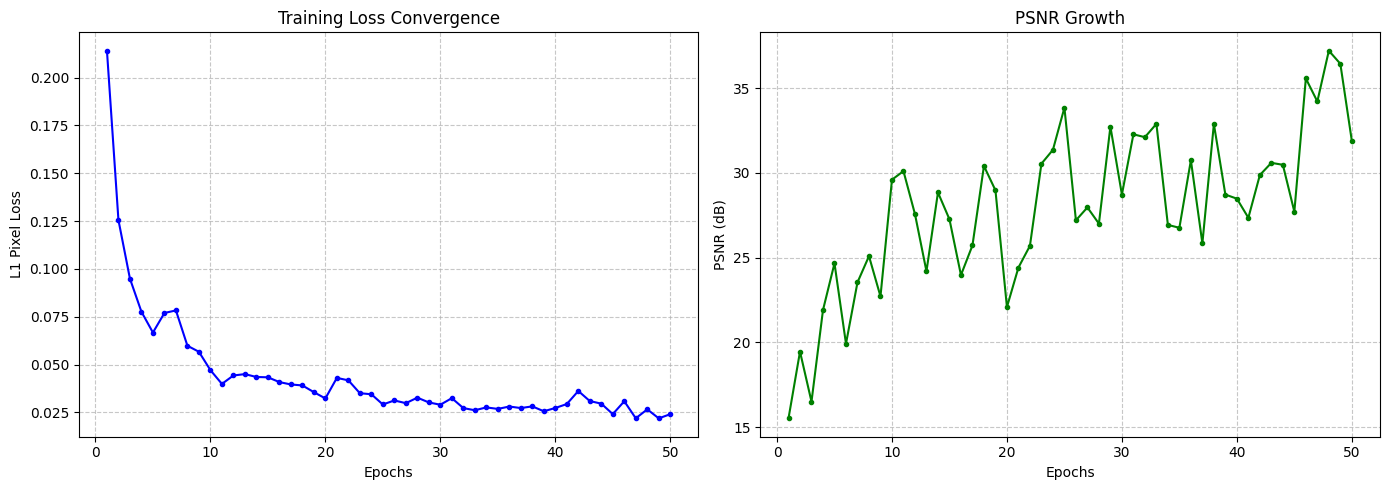

In [ ]:
def plot_convergence(losses, psnrs):
    """Plots the training loss and PSNR side-by-side."""
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: L1 Loss Curve
    ax[0].plot(range(1, len(losses)+1), losses, color='blue', marker='o', markersize=3)
    ax[0].set_title("Training Loss Convergence")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("L1 Pixel Loss")
    ax[0].grid(True, linestyle='--', alpha=0.7)

    # Plot 2: PSNR Curve
    ax[1].plot(range(1, len(psnrs)+1), psnrs, color='green', marker='o', markersize=3)
    ax[1].set_title("PSNR Growth")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("PSNR (dB)")
    ax[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Trigger the plot using the lists we populated during training
plot_convergence(history_loss, history_psnr)

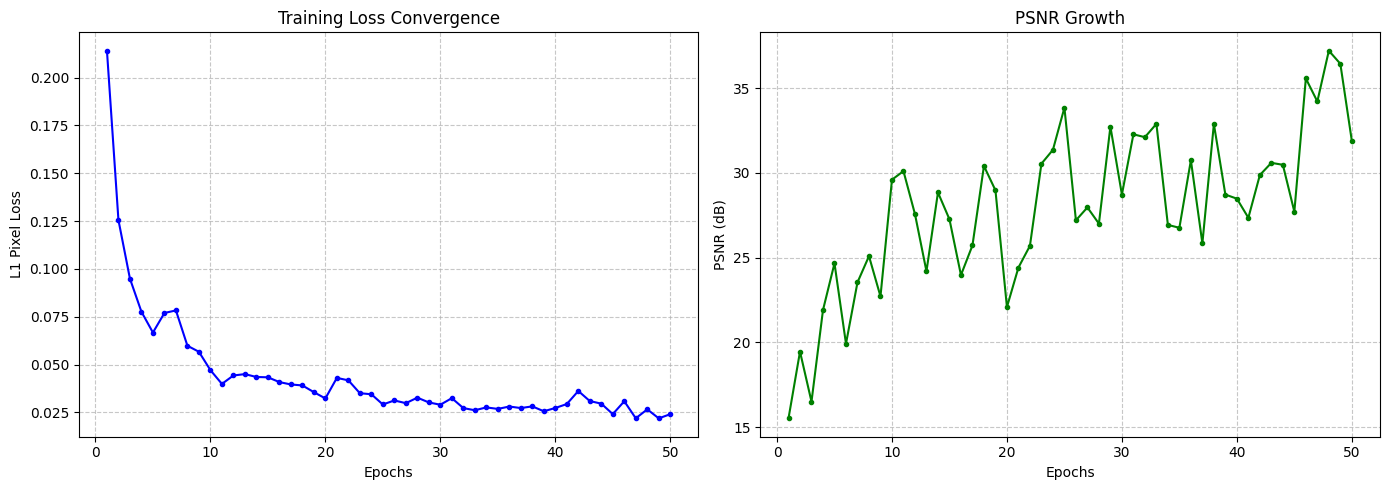

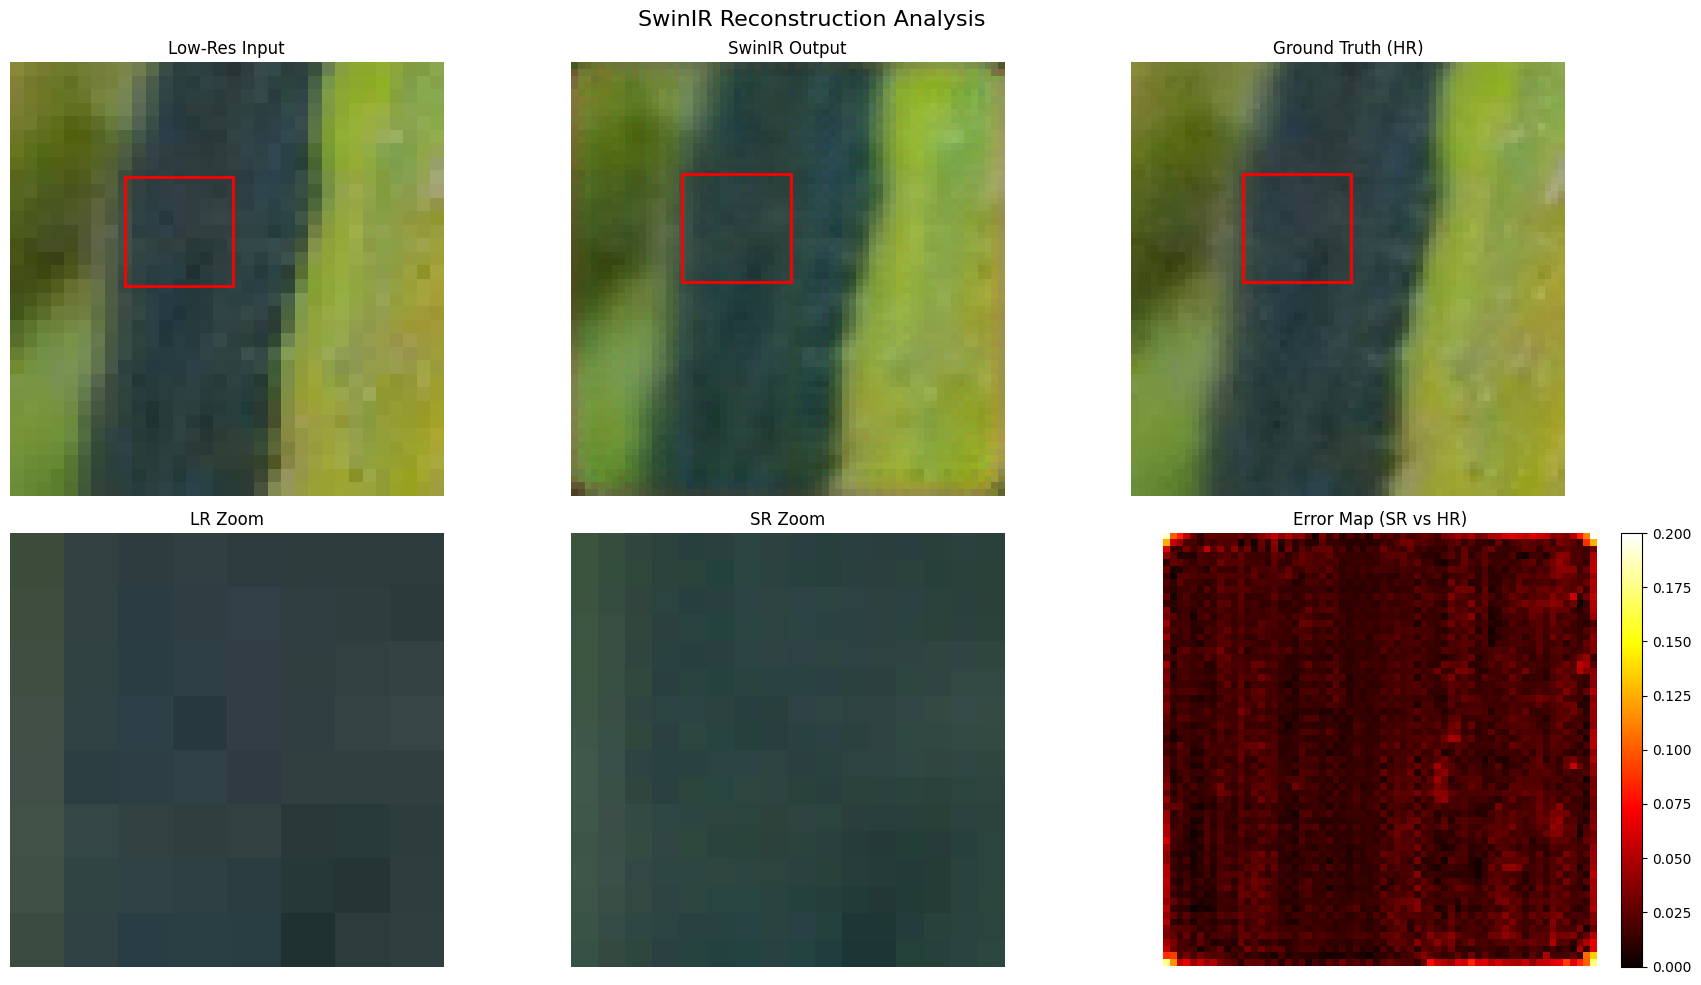

In [ ]:
# 1. Show the Loss and PSNR curves
plot_convergence(history_loss, history_psnr)

# 2. Show the zoomed visuals and error maps for the test image
# (Adjust zoom_coord to point to an interesting edge/texture in your specific image)
plot_advanced_results(test_lr, test_sr, test_hr, zoom_coord=(16, 16), zoom_size=16)